In [1]:
import torch

import triton
import triton.language as tl
from triton.runtime import driver

DEVICE = triton.runtime.driver.active.get_active_torch_device()

In [2]:
DEVICE

device(type='cuda', index=0)

In [3]:

def is_hip():
    return triton.runtime.driver.active.get_current_target().backend == "hip"



def is_cdna():
    return is_hip() and triton.runtime.driver.active.get_current_target().arch in ('gfx940', 'gfx941', 'gfx942',
                                                                                   'gfx90a', 'gfx908')
def naive_softmax(x):
    """Compute row-wise softmax of X using native pytorch

    We subtract the maximum element in order to avoid overflows. Softmax is invariant to
    this shift.
    """

    """
    なぜ私はnaive_softmaxの関数を作ろうとおもったのが。僕が今ときたいとおもっている課題は何か。
    まあ motivationはよくわからんけど、単純な加算をやりたくなったのはまちがいなさそうだ。
    """
    # xはたぶんtorchなんでしょう

    # read  MN elements ; write M  elements
    x_max = x.max(dim=1)[0]
    # read MN + M elements ; write MN elements
    # readとかwriteとかが何をやっているかはわからないが、標準化していることはわかる
    z = x - x_max[:, None]
    # read  MN elements ; write MN elements
    numerator = torch.exp(z)
    # read  MN elements ; write M  elements
    denominator = numerator.sum(dim=1)

    # read MN + M elements ; write MN elements
    ret = numerator / denominator[:, None]
    # in total: read 5MN + 2M elements ; wrote 3MN + 2M elements
    return ret

    

    

In [4]:
"""
torchは演算ごとに独立したkernelを起動して、

torchが自前のkernelをもっていて、DRAM に書き込んでいる=write M elements
DRAMは情報を保持している、SRAMは速いが情報を保持していない。
この例では、（reading 5⁢𝑀⁢𝑁 +2⁢𝑀 elements from DRAM and writing back 3⁢𝑀⁢𝑁 +2⁢𝑀 elements.）　分のioが発生している。
チップ上にのるような小さな計算であれば、最適化できそうだなって感じが今回のtutorial.
"""

'\ntorchは演算ごとに独立したkernelを起動して、\n\ntorchが自前のkernelをもっていて、DRAM に書き込んでいる=write M elements\nDRAMは情報を保持している、SRAMは速いが情報を保持していない。\nこの例では、（reading 5\u2062𝑀\u2062𝑁 +2\u2062𝑀 elements from DRAM and writing back 3\u2062𝑀\u2062𝑁 +2\u2062𝑀 elements.）\u3000分のioが発生している。\nチップ上にのるような小さな計算であれば、最適化できそうだなって感じが今回のtutorial.\n'

In [5]:
"""
予測をたてるべき

全体を分子として、8MN + 4M(要素) の読み書き(メモリトラフィック)が発生する
最初に読み込む1回と、書き込む1回は固定なので、2MNはfused版の総トラフィック

なのでこれを計算して、　(8MN + 4M)/2MN = 4 + 2/N (N が大きくなるほど、~4xに近づく、となる)
帯域律速なら、~4xに近づくことが期待できる
"""

'\n予測をたてるべき\n\n全体を分子として、8MN + 4M(要素) の読み書き(メモリトラフィック)が発生する\n最初に読み込む1回と、書き込む1回は固定なので、2MNはfused版の総トラフィック\n\nなのでこれを計算して、\u3000(8MN + 4M)/2MN = 4 + 2/N (N が大きくなるほど、~4xに近づく、となる)\n帯域律速なら、~4xに近づくことが期待できる\n'

In [6]:
@triton.jit
def softmax_kernel(output_ptr, input_ptr, input_row_stride, output_row_stride, n_rows, n_cols, BLOCK_SIZE: tl.constexpr,num_stages: tl.constexpr):
    # programはthread的なものって考えよう
    # なんで0??
    row_start = tl.program_id(0)
    row_step = tl.num_programs(0)
    # tl.device_print("hello")
    for row_idx in tl.range(row_start, n_rows, row_step, num_stages=num_stages):
        # The stride represents how much we need to increase the pointer to advance 1 row
        row_start_ptr = input_ptr + row_idx * input_row_stride
        # tl.device_print("row_idx", row_idx)

        # 全部0のmatrixがはいってる
        col_offsets = tl.arange(0, BLOCK_SIZE)
        input_ptrs = row_start_ptr + col_offsets
        # Load the row into SRAM, using a mask since BLOCK_SIZE may be > than n_cols
        mask = col_offsets < n_cols
        row = tl.load(input_ptrs, mask=mask, other=-float('inf'))
         # Subtract maximum for numerical stability
        row_minus_max = row - tl.max(row, axis=0)
         # Note that exponentiation in Triton is fast but approximate (i.e., think __expf in CUDA)
        numerator = tl.exp(row_minus_max)
        denominator = tl.sum(numerator, axis=0)
        softmax_output = numerator / denominator

        # Write back output to DRAM
        output_row_start_ptr = output_ptr + row_idx * output_row_stride
        output_ptrs = output_row_start_ptr + col_offsets
        tl.store(output_ptrs, softmax_output, mask=mask)
        
        





    

In [7]:
properties = driver.active.utils.get_device_properties(DEVICE.index)
SIZE_SMEM = properties["max_shared_mem"]
NUM_REGS = properties["max_num_regs"]
SIZE_STEM = properties["max_shared_mem"]
WARP_SIZE = properties["warpSize"]
NUM_SM = properties["multiprocessor_count"]
target = triton.runtime.driver.active.get_current_target()
kernels = {}

def softmax(x):
    n_rows, n_cols = x.shape
    # print(n_rows, n_cols)
    # BLOCK_SIZEをもとめる.xの列数より大きい最小の二のべき乗を採用する
    BLOCK_SIZE = triton.next_power_of_2(n_cols)

    # なんでそれを二のべき乗に??
    # 二のべき乗である必要として、tritonが仕様として持っている制限がある
    # 全体のなんかの制限を求めるというか、BLOCK_SIZEだから処理の最小単位よね。
    # なら、最小のべき乗を最小するのはわかる。が、xの列数がなぜそこで出てくるんだろう。
    # print(BLOCK_SIZE)

    # Another trick we can use is to ask the compiler to use more threads per row by
    # increasing the number of warps (`num_warps`) over which each row is distributed.
    # You will see in the next tutorial how to auto-tune this value in a more natural
    # way so you don't have to come up with manual heuristics yourself.
    # データによってここは変わる変数となる。今回は練習のために決め打ちなだけ
    num_warps = 8

    # Number of software pipelining stages.
    # 空き領域のチェックかな
    num_stages = 4 if SIZE_SMEM > 200000 else 2
    # print(num_stages)

    # Allocate output
    y = torch.empty_like(x)

    kernel = softmax_kernel.warmup(  # pyright: ignore[reportFunctionMemberAccess]
        y,
        x,
        x.stride(0),
        y.stride(0),
        n_rows,
        n_cols,
        BLOCK_SIZE=BLOCK_SIZE,
        num_stages=num_stages,
        num_warps=num_warps,
        grid=(1,)
    )

    kernel._init_handles()
    n_regs = kernel.n_regs
    size_smem = kernel.metadata.shared

    if is_hip():
        # print("is_hip")
        NUM_GPRS = NUM_REGS
        if is_cdna():
            NUM_GPRS = NUM_REGS * 2

        MAX_NUM_THREADS = properties["max_threads_per_sm"]
        max_num_waves = MAX_NUM_THREADS // WARP_SIZE
        occupancy = min(NUM_GPRS // WARP_SIZE // n_regs, max_num_waves) // num_warps
    else:
        # print("not is_hip")
        occupancy = NUM_REGS // (n_regs * WARP_SIZE * num_warps)
        # print("NUM_REGS", NUM_REGS)
    occupancy = min(occupancy, SIZE_SMEM // size_smem)
    num_programs = NUM_SM * occupancy
    # print("num_programs", num_programs)
    
    num_programs = min(num_programs, n_rows)
    # Create a number of persistent programs.
    kernel[(num_programs, 1, 1)](y, x, x.stride(0), y.stride(0), n_rows, n_cols, BLOCK_SIZE, num_stages)
    return y

        
        
    
    
    
        

    
    

In [8]:
torch.manual_seed(0)
x = torch.randn(1823, 781, device=DEVICE)
y_triton = softmax(x)
y_torch = torch.softmax(x, axis=1)
assert torch.allclose(y_triton, y_torch), (y_triton, y_torch)

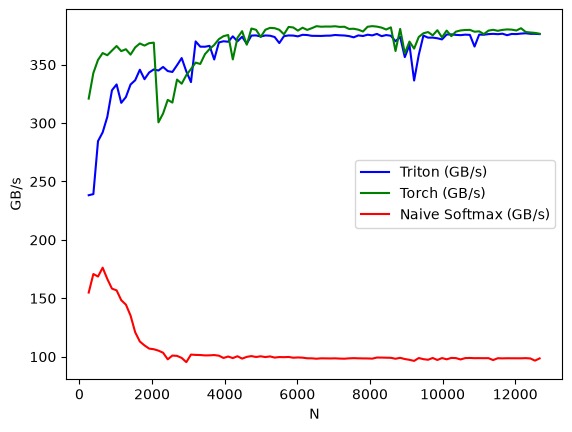

softmax-performance:
          N  Triton (GB/s)  Torch (GB/s)  Naive Softmax (GB/s)
0     256.0     238.241716    320.968088            154.901361
1     384.0     239.201814    342.904978            170.785779
2     512.0     284.565941    354.125688            168.610451
3     640.0     292.054659    359.979767            176.211875
4     768.0     305.333501    358.109581            166.557818
5     896.0     328.110236    362.104872            158.265732
6    1024.0     333.109104    366.014275            156.790241
7    1152.0     317.328841    361.600187            148.357468
8    1280.0     322.302053    363.254490            144.592941
9    1408.0     333.051880    358.616691            135.239231
10   1536.0     336.715303    364.818098            120.897540
11   1664.0     345.710002    368.190952            112.997410
12   1792.0     337.570476    366.372762            109.646340
13   1920.0     343.326857    368.423550            106.933681
14   2048.0     345.955306    368.

In [9]:
# Benchmark




@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],  # argument names to use as an x-axis for the plot
        x_vals=[128 * i for i in range(2, 100)],  # different possible values for `x_name`
        line_arg='provider',  # argument name whose value corresponds to a different line in the plot
        line_vals=['triton', 'torch', 'naive_softmax'],  # possible values for `line_arg``
        line_names=["Triton", "Torch", "Naive Softmax"],  # label name for the lines
        styles=[('blue', '-'), ('green', '-'), ('red', '-')],  # line styles
        ylabel="GB/s",  # label name for the y-axis
        plot_name="softmax-performance",  # name for the plot. Used also as a file name for saving the plot.
        args={'M': 4096},  # values for function arguments not in `x_names` and `y_name`
    ))
def benchmark(M,N,provider):
    torch.cuda.empty_cache()
    x = torch.randn(M,N, device=DEVICE, dtype=torch.float32)
    stream = getattr(torch, DEVICE.type).Stream()
    getattr(torch, DEVICE.type).set_stream(stream)
    if provider == 'torch':
        ms = triton.testing.do_bench(lambda: torch.softmax(x, axis=-1))
    if provider == 'triton':
        ms = triton.testing.do_bench(lambda: softmax(x))
    if provider == 'naive_softmax':
        ms = triton.testing.do_bench(lambda: naive_softmax(x))
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms)

benchmark.run(show_plots=True, print_data=True)